# Лабораторная работа №6 — Кластеризация данных
## Алгоритмы: K-Means, MeanShift, AgglomerativeClustering, DBSCAN

**Датасет:** `Wine` (UCI / sklearn) — 178 образцов, 13 признаков, 3 истинных класса  
**Цель:** сравнить алгоритмы кластеризации, подобрать гиперпараметры, оценить качество методами silhouette и elbow.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans, MeanShift, AgglomerativeClustering, DBSCAN,
    estimate_bandwidth
)
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.model_selection import ParameterGrid, ParameterSampler

# Настройки файла

In [3]:
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans',
})
RANDOM_STATE = 42

## 1. Загрузка данных и первичный анализ
Используем датасет **Wine** — результаты химического анализа вин из трёх регионов Италии.  
Признаки включают алкоголь, кислотность, флавоноиды, цвет и т.д.  
Метки классов (`target`) **не используются при обучении**, только для финальной валидации.


In [4]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target               

print(f"Размер датасета : {X.shape[0]} образцов × {X.shape[1]} признаков")
print(f"Истинных классов: {len(np.unique(y))}  ({np.bincount(y)} образцов в каждом)")
print()
X.describe().round(2)

Размер датасета : 178 образцов × 13 признаков
Истинных классов: 3  ([59 71 48] образцов в каждом)



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


Пропущенные значения: 0


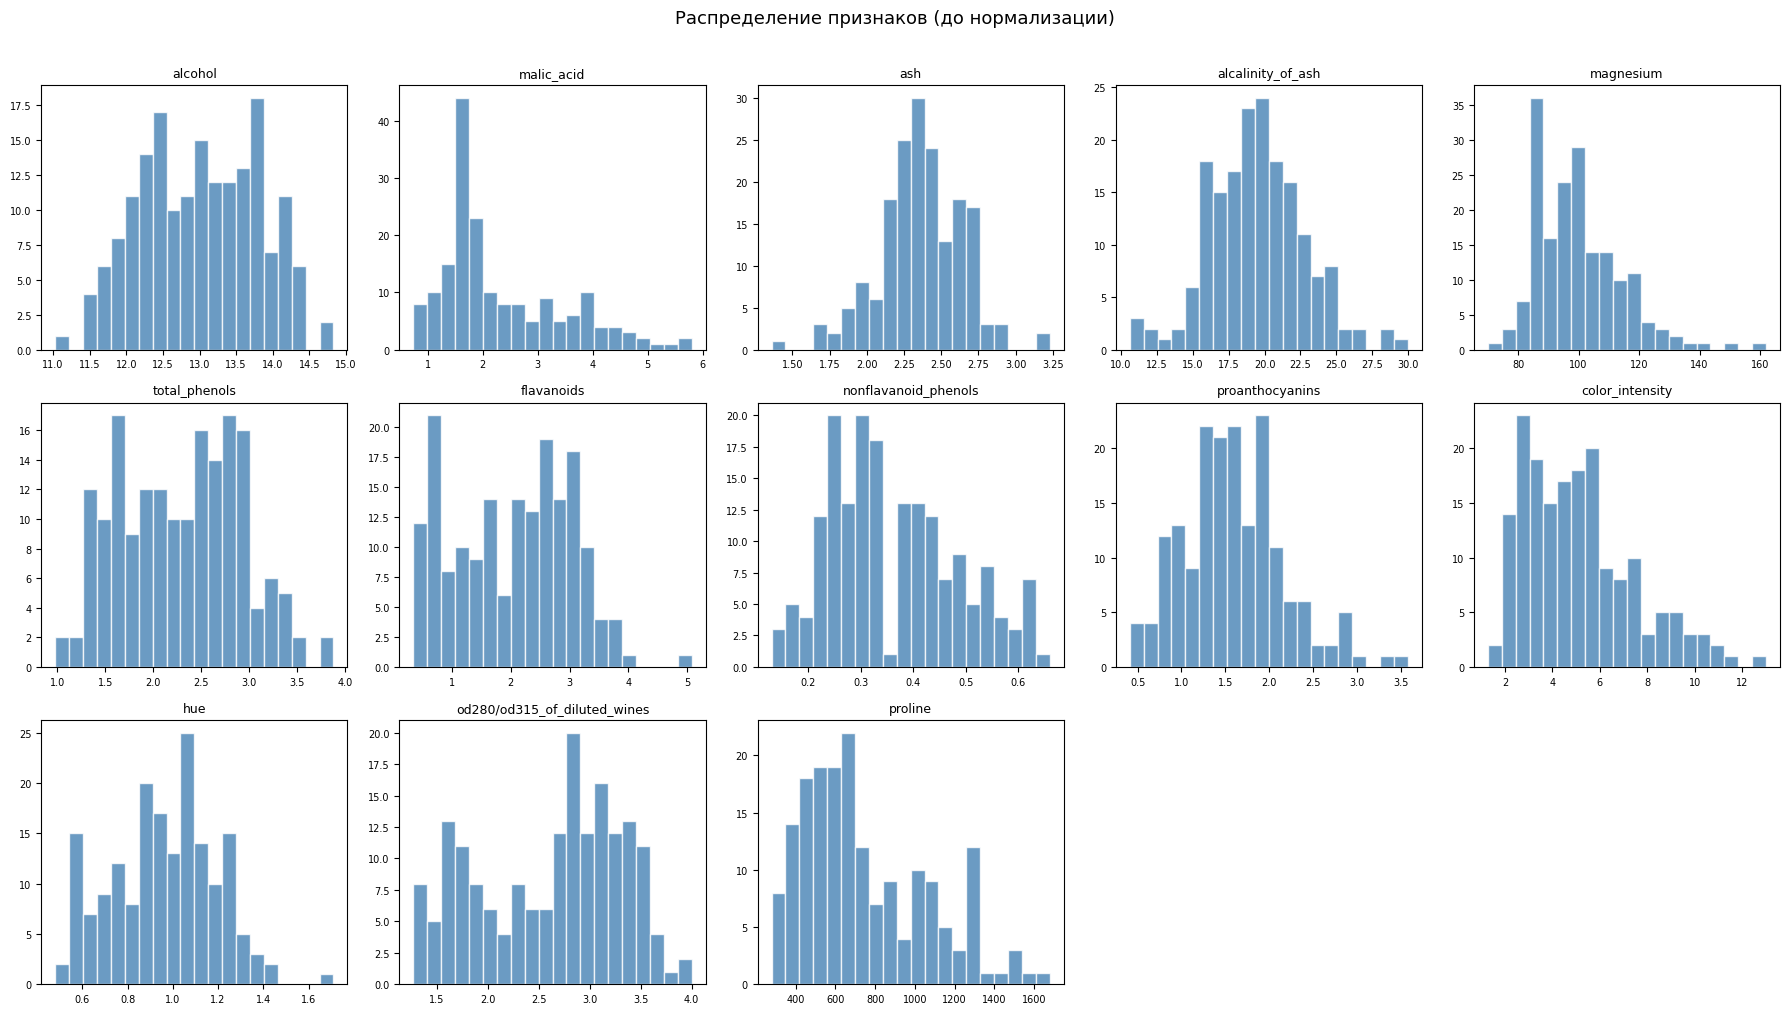

In [5]:
# проверка на пропуски и базовая статистика
print("Пропущенные значения:", X.isnull().sum().sum())

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Распределение признаков (до нормализации)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. Предобработка в Pipeline
Все алгоритмы кластеризации чувствительны к масштабу признаков.  
`Pipeline` гарантирует, что нормализация применяется **только на тренировочных данных** —  
это предотвращает утечку статистики при кросс-валидации.

**Состав пайплайна:**
| Шаг | Класс | Назначение |
|-----|-------|-----------|
| `scaler` | `StandardScaler` | Z-нормализация: μ=0, σ=1 для каждого признака |
| `pca_2d` | `PCA(n_components=2)` | Только для **визуализации**; модели обучаются на полных 13 признаках |

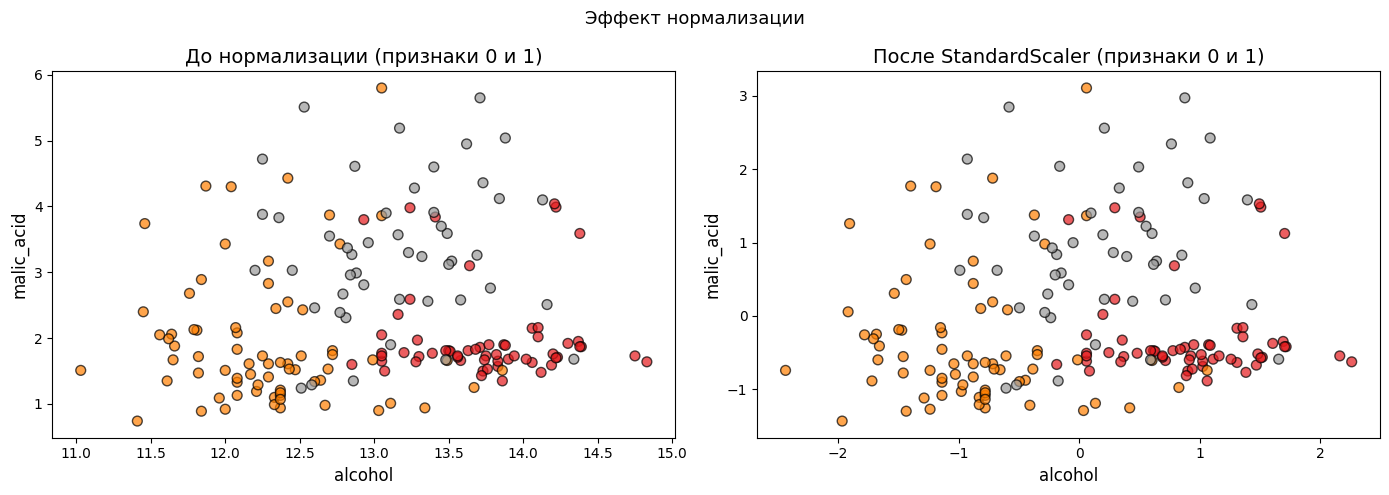

Дисперсия, объясняемая первыми двумя PC: 55.4%


In [6]:
# пайплайн для моделирования
preprocessing = Pipeline([
    ('scaler', StandardScaler())
])

X_scaled = preprocessing.fit_transform(X)

# отдельный пайплайн для 2D-визуализации
viz_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=2, random_state=RANDOM_STATE))
])

X_2d = viz_pipeline.fit_transform(X)

# наглядность: как нормализация меняет данные
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='Set1', alpha=0.7, edgecolors='k', s=50)
axes[0].set_title("До нормализации (признаки 0 и 1)")
axes[0].set_xlabel(X.columns[0]); axes[0].set_ylabel(X.columns[1])

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='Set1', alpha=0.7, edgecolors='k', s=50)
axes[1].set_title("После StandardScaler (признаки 0 и 1)")
axes[1].set_xlabel(X.columns[0]); axes[1].set_ylabel(X.columns[1])

plt.suptitle("Эффект нормализации", fontsize=13)
plt.tight_layout(); plt.show()

print(f"Дисперсия, объясняемая первыми двумя PC: "
      f"{viz_pipeline['pca'].explained_variance_ratio_.sum():.1%}")

## 3. K-Means и метод локтя (Elbow Method)
**K-Means** разбивает данные на *K* кластеров, минимизируя суммарное внутрикластерное  
рассеяние (инерцию — SSE). Алгоритм чувствителен к выбору *K*.

**Метод локтя** — строим инерцию vs K и ищем точку, после которой снижение замедляется  
(«локоть»). Дополнительно строим кривую **Silhouette** для подтверждения выбора.


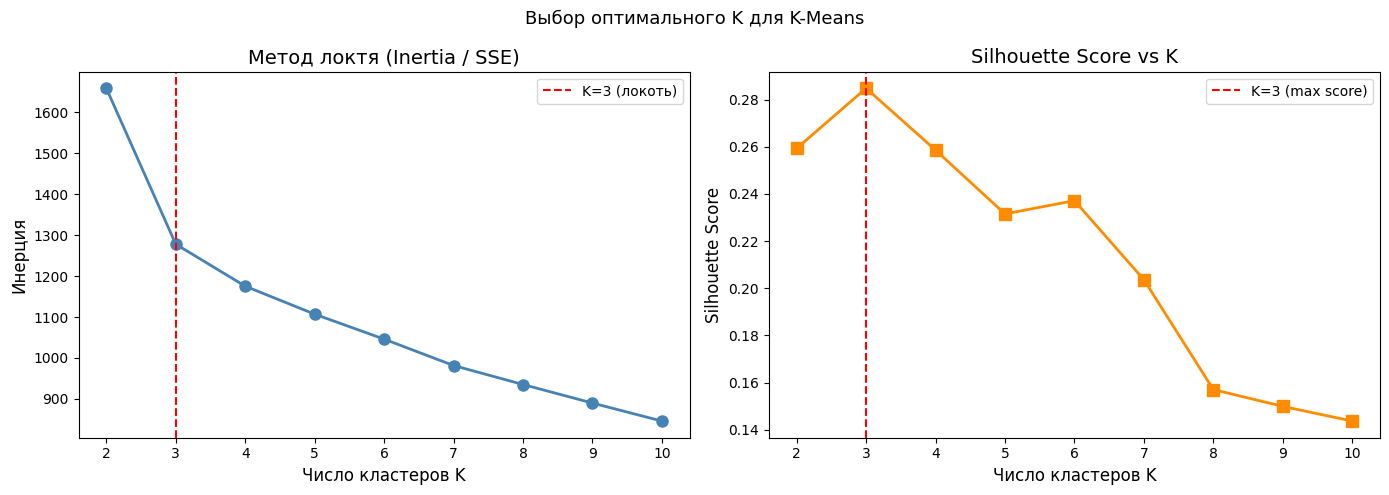

Оптимальное K по silhouette : 3
Max silhouette              : 0.2849


In [7]:
# метод локтя + silhouette по диапазону K
K_range = range(2, 11)
inertias, silhouettes = [], []

for k in K_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('km',     KMeans(n_clusters=k, init='k-means++', n_init=20,
                          random_state=RANDOM_STATE))
    ])
    pipe.fit(X)
    labels = pipe['km'].labels_
    inertias.append(pipe['km'].inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title("Метод локтя (Inertia / SSE)")
axes[0].set_xlabel("Число кластеров K"); axes[0].set_ylabel("Инерция")
axes[0].axvline(x=3, color='red', linestyle='--', label='K=3 (локоть)')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 's-', color='darkorange', linewidth=2, markersize=8)
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Число кластеров K"); axes[1].set_ylabel("Silhouette Score")
axes[1].axvline(x=3, color='red', linestyle='--', label='K=3 (max score)')
axes[1].legend()

plt.suptitle("Выбор оптимального K для K-Means", fontsize=13)
plt.tight_layout(); plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Оптимальное K по silhouette : {best_k}")
print(f"Max silhouette              : {max(silhouettes):.4f}")

## 4. Подбор гиперпараметров: Grid Search и Random Search

Стандартный `GridSearchCV` не предназначен для задач без учителя.  
**Профессиональный подход** — ручной перебор с оценкой через `silhouette_score`,  
`davies_bouldin_score` и `calinski_harabasz_score`.

> `ParameterGrid` и `ParameterSampler` из `sklearn.model_selection`  
> воспроизводят логику Grid/Random Search без привязки к `fit/predict` API.


In [8]:
# Grid Search
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6],
    'init':       ['k-means++', 'random'],
    'max_iter':   [100, 300, 500],
}

grid_results = []
for params in ParameterGrid(param_grid):
    km = KMeans(**params, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    # Пропускаем вырожденные разбиения (один кластер на всё)
    if len(set(labels)) < 2:
        continue
    grid_results.append({
        **params,
        'silhouette':  round(silhouette_score(X_scaled, labels), 4),
        'davies_bouldin': round(davies_bouldin_score(X_scaled, labels), 4),
        'calinski':    round(calinski_harabasz_score(X_scaled, labels), 2),
        'inertia':     round(km.inertia_, 2),
    })

df_grid = pd.DataFrame(grid_results).sort_values('silhouette', ascending=False)
print("── Grid Search: топ-10 конфигураций ──")
print(df_grid.head(10).to_string(index=False))

── Grid Search: топ-10 конфигураций ──
     init  max_iter  n_clusters  silhouette  davies_bouldin  calinski  inertia
k-means++       100           3      0.2849          1.3892     70.94  1277.93
k-means++       300           3      0.2849          1.3892     70.94  1277.93
k-means++       500           3      0.2849          1.3892     70.94  1277.93
   random       500           3      0.2849          1.3892     70.94  1277.93
   random       300           3      0.2849          1.3892     70.94  1277.93
   random       100           3      0.2849          1.3892     70.94  1277.93
   random       300           2      0.2683          1.4482     69.49  1659.01
   random       500           2      0.2683          1.4482     69.49  1659.01
   random       100           2      0.2683          1.4482     69.49  1659.01
k-means++       500           4      0.2602          1.7969     56.18  1175.43


In [9]:
# Random Search
param_dist = {
    'n_clusters': list(range(2, 9)),
    'init':       ['k-means++', 'random'],
    'max_iter':   [50, 100, 200, 300, 500, 1000],
}

random_results = []
for params in ParameterSampler(param_dist, n_iter=30, random_state=RANDOM_STATE):
    km = KMeans(**params, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    if len(set(labels)) < 2:
        continue
    random_results.append({
        **params,
        'silhouette':  round(silhouette_score(X_scaled, labels), 4),
        'davies_bouldin': round(davies_bouldin_score(X_scaled, labels), 4),
        'calinski':    round(calinski_harabasz_score(X_scaled, labels), 2),
    })

df_random = pd.DataFrame(random_results).sort_values('silhouette', ascending=False)
print("── Random Search: топ-10 конфигураций ──")
print(df_random.head(10).to_string(index=False))

# итоговая лучшая конфигурация
best_params = df_grid.iloc[0][['n_clusters', 'init', 'max_iter']].to_dict()
best_params['n_clusters'] = int(best_params['n_clusters'])
best_params['max_iter']   = int(best_params['max_iter'])
print(f"\nЛучшие параметры (Grid Search): {best_params}")

── Random Search: топ-10 конфигураций ──
 n_clusters  max_iter      init  silhouette  davies_bouldin  calinski
          3       300 k-means++      0.2849          1.3892     70.94
          2       500    random      0.2683          1.4482     69.49
          2        50    random      0.2683          1.4482     69.49
          2       100    random      0.2683          1.4482     69.49
          4       100 k-means++      0.2602          1.7969     56.18
          4       500 k-means++      0.2602          1.7969     56.18
          2        50 k-means++      0.2593          1.5260     69.52
          2      1000 k-means++      0.2593          1.5260     69.52
          2       500 k-means++      0.2593          1.5260     69.52
          4       300    random      0.2517          1.8172     56.15

Лучшие параметры (Grid Search): {'n_clusters': 3, 'init': 'k-means++', 'max_iter': 100}


### Силуэтный график (Silhouette Plot)
Каждая горизонтальная полоса — один образец. Ширина полосы = значение силуэта.  
- Все полосы должны быть **шире среднего** (вертикальная красная линия)  
- Ширины полос кластеров должны быть **примерно одинаковыми** (нет доминирующего кластера)


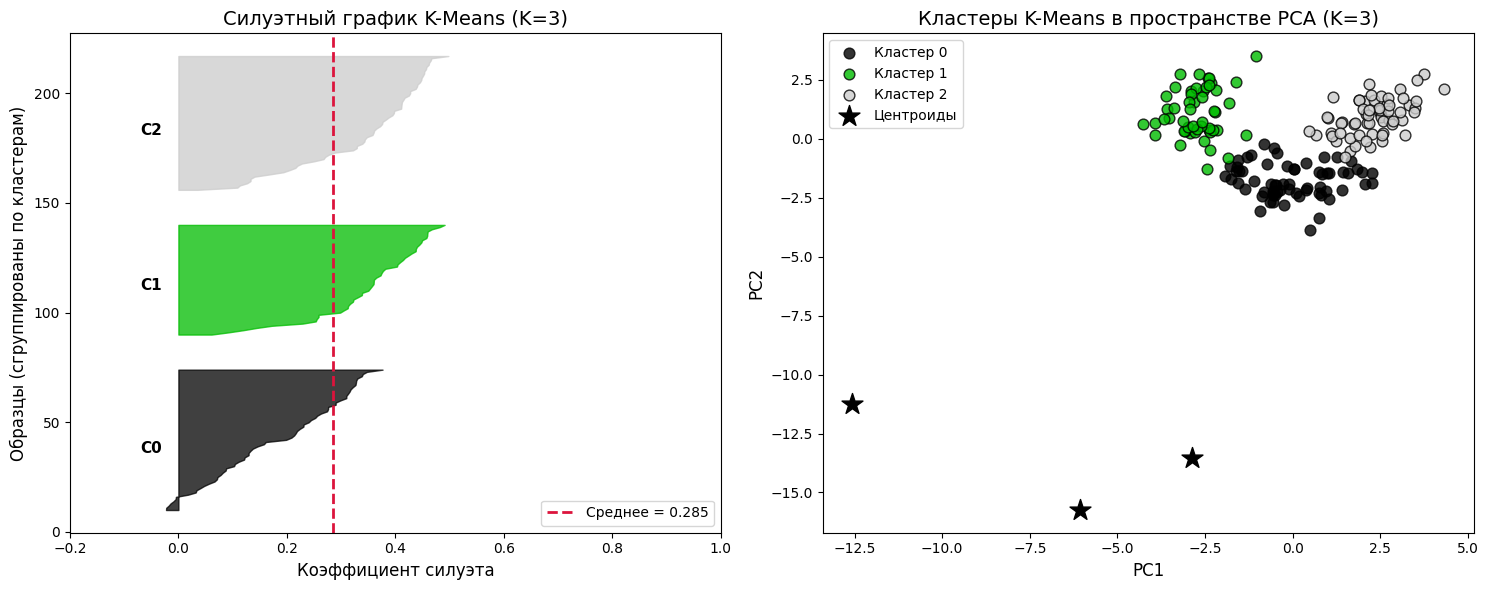

Silhouette Score : 0.2849
Davies-Bouldin   : 1.3892  (чем меньше — тем лучше)
Calinski-Harabasz: 70.94  (чем больше — тем лучше)


In [10]:
# Silhouette Plot для лучшей K-Means конфигурации 
n_clusters = int(best_params['n_clusters'])
km_best = KMeans(n_clusters=n_clusters, init=best_params['init'],
                 max_iter=int(best_params['max_iter']),
                 n_init=20, random_state=RANDOM_STATE)
labels_km = km_best.fit_predict(X_scaled)

sil_vals   = silhouette_samples(X_scaled, labels_km)
sil_avg    = silhouette_score(X_scaled, labels_km)
colors_map = cm.nipy_spectral(np.linspace(0, 1, n_clusters))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# левый: силуэтный график
y_lower = 10
for i in range(n_clusters):
    cluster_sil = np.sort(sil_vals[labels_km == i])
    size        = cluster_sil.shape[0]
    y_upper     = y_lower + size
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=colors_map[i], edgecolor=colors_map[i], alpha=0.75)
    ax1.text(-0.07, y_lower + 0.4 * size, f"C{i}", fontsize=11, fontweight='bold')
    y_lower = y_upper + 15

ax1.axvline(x=sil_avg, color='crimson', linestyle='--', linewidth=2,
            label=f'Среднее = {sil_avg:.3f}')
ax1.set_xlim(-0.2, 1.0)
ax1.set_xlabel("Коэффициент силуэта"); ax1.set_ylabel("Образцы (сгруппированы по кластерам)")
ax1.set_title(f"Силуэтный график K-Means (K={n_clusters})")
ax1.legend(loc='lower right')

# правый: пространство кластеров (PCA 2D)
for i in range(n_clusters):
    mask = labels_km == i
    ax2.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=[colors_map[i]], label=f"Кластер {i}",
                edgecolors='k', s=60, alpha=0.8)
centers_2d = viz_pipeline['pca'].transform(
    viz_pipeline['scaler'].transform(km_best.cluster_centers_))
ax2.scatter(centers_2d[:, 0], centers_2d[:, 1],
            marker='*', s=250, c='black', zorder=5, label='Центроиды')
ax2.set_title(f"Кластеры K-Means в пространстве PCA (K={n_clusters})")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2"); ax2.legend()

plt.tight_layout(); plt.show()
print(f"Silhouette Score : {sil_avg:.4f}")
print(f"Davies-Bouldin   : {davies_bouldin_score(X_scaled, labels_km):.4f}  (чем меньше — тем лучше)")
print(f"Calinski-Harabasz: {calinski_harabasz_score(X_scaled, labels_km):.2f}  (чем больше — тем лучше)")

## 5. MeanShift
**MeanShift** — неpараметрический алгоритм: **не требует задавать число кластеров**.  
Находит плотные области пространства признаков, сдвигая каждую точку в направлении  
максимального локального градиента плотности (kernel density estimation).

**Ключевой параметр:** `bandwidth` — «ширина окна» (радиус поиска).  
`estimate_bandwidth` подбирает его автоматически по квантильному правилу.


Автоматически подобранный bandwidth: 3.5511
Найдено кластеров: 6
Silhouette       : 0.2207
Davies-Bouldin   : 0.9828
Calinski-Harabasz: 18.91


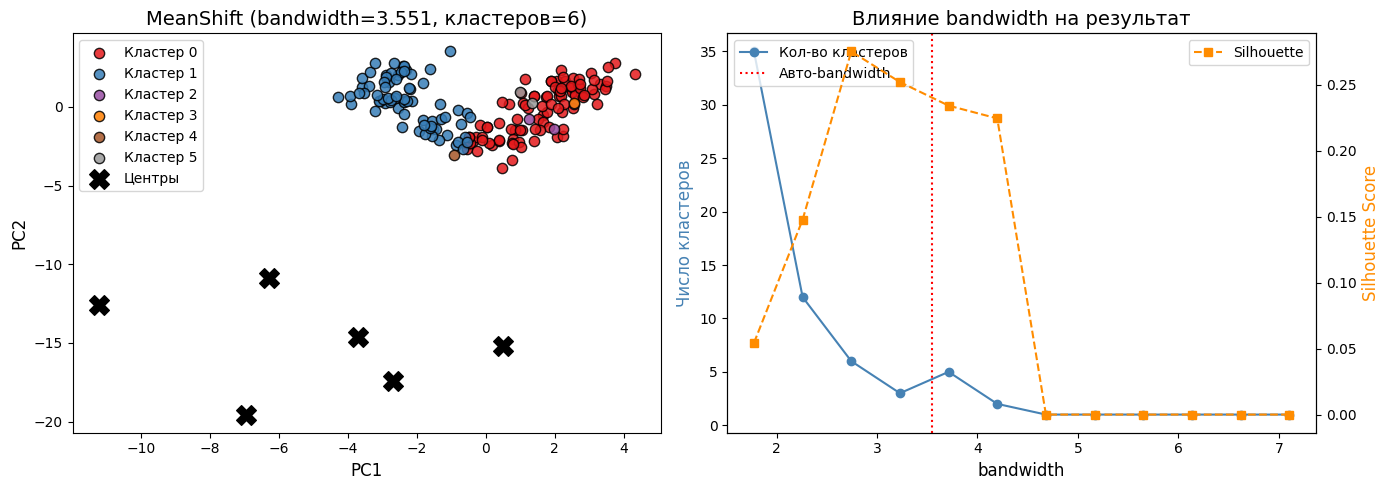

In [11]:
# подбор bandwidth через estimate_bandwidth
bw = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=len(X_scaled),
                        random_state=RANDOM_STATE)
print(f"Автоматически подобранный bandwidth: {bw:.4f}")

# обучение
ms = MeanShift(bandwidth=bw, bin_seeding=True)
labels_ms = ms.fit_predict(X_scaled)
n_clusters_ms = len(np.unique(labels_ms))
print(f"Найдено кластеров: {n_clusters_ms}")

# метрики
if n_clusters_ms > 1:
    sil_ms = silhouette_score(X_scaled, labels_ms)
    db_ms  = davies_bouldin_score(X_scaled, labels_ms)
    ch_ms  = calinski_harabasz_score(X_scaled, labels_ms)
    print(f"Silhouette       : {sil_ms:.4f}")
    print(f"Davies-Bouldin   : {db_ms:.4f}")
    print(f"Calinski-Harabasz: {ch_ms:.2f}")

# визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = cm.Set1(np.linspace(0, 0.9, n_clusters_ms))

for i, color in enumerate(palette):
    mask = labels_ms == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=[color], label=f"Кластер {i}", edgecolors='k', s=55, alpha=0.85)
centers_2d_ms = viz_pipeline.transform(ms.cluster_centers_)
axes[0].scatter(centers_2d_ms[:, 0], centers_2d_ms[:, 1],
                marker='X', s=200, c='black', zorder=5, label='Центры')
axes[0].set_title(f"MeanShift (bandwidth={bw:.3f}, кластеров={n_clusters_ms})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

# влияние bandwidth на число кластеров 
bw_vals = np.linspace(bw * 0.5, bw * 2, 12)
n_clusters_list = []
sil_list = []
for b in bw_vals:
    try:
        ms_tmp = MeanShift(bandwidth=b, bin_seeding=True)
        lbl = ms_tmp.fit_predict(X_scaled)
        nc  = len(np.unique(lbl))
        n_clusters_list.append(nc)
        sil_list.append(silhouette_score(X_scaled, lbl) if nc > 1 else 0)
    except Exception:
        n_clusters_list.append(np.nan)
        sil_list.append(np.nan)

ax2b = axes[1].twinx()
axes[1].plot(bw_vals, n_clusters_list, 'o-', color='steelblue', label='Кол-во кластеров')
ax2b.plot(bw_vals, sil_list, 's--', color='darkorange', label='Silhouette')
axes[1].set_xlabel("bandwidth"); axes[1].set_ylabel("Число кластеров", color='steelblue')
ax2b.set_ylabel("Silhouette Score", color='darkorange')
axes[1].axvline(x=bw, color='red', linestyle=':', label='Авто-bandwidth')
axes[1].set_title("Влияние bandwidth на результат")
axes[1].legend(loc='upper left'); ax2b.legend(loc='upper right')

plt.tight_layout(); plt.show()

## 6. AgglomerativeClustering (иерархическая кластеризация)
**AgglomerativeClustering** строит дерево (дендрограмму) слиянием ближайших кластеров  
снизу вверх. Не требует предварительно знать *K*, но *K* задаётся при срезе дерева.

**Ключевые параметры:**
| Параметр | Роль |
|----------|------|
| `n_clusters` | Число кластеров при финальном срезе |
| `linkage` | Критерий близости: `ward`, `complete`, `average`, `single` |
| `metric` | Метрика расстояния (при `linkage != 'ward'`) |


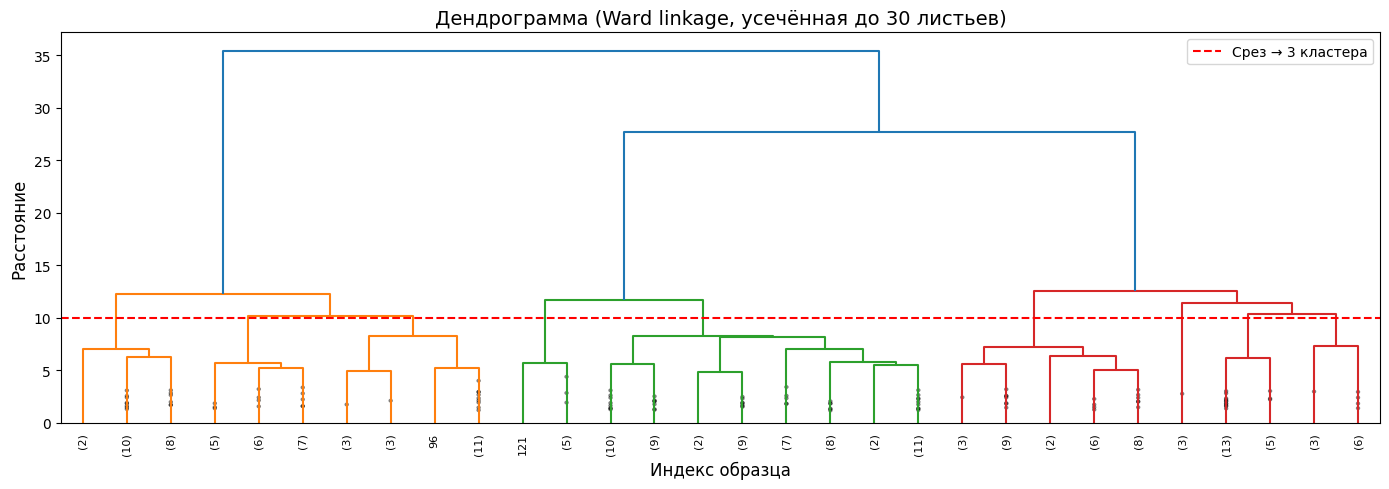

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage as sp_linkage

# дендрограмма (scipy)
fig, ax = plt.subplots(figsize=(14, 5))
Z = sp_linkage(X_scaled, method='ward')
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True)
ax.set_title("Дендрограмма (Ward linkage, усечённая до 30 листьев)")
ax.set_xlabel("Индекс образца"); ax.set_ylabel("Расстояние")
ax.axhline(y=10, color='red', linestyle='--', label='Срез → 3 кластера')
ax.legend()
plt.tight_layout(); plt.show()

In [13]:
# сравнение стратегий linkage
linkages   = ['ward', 'complete', 'average', 'single']
n_cl_range = [2, 3, 4, 5]

linkage_results = []
for lnk in linkages:
    for nc in n_cl_range:
        metric = 'euclidean' if lnk == 'ward' else 'euclidean'
        model  = AgglomerativeClustering(n_clusters=nc, linkage=lnk)
        lbl    = model.fit_predict(X_scaled)
        if len(set(lbl)) < 2:
            continue
        linkage_results.append({
            'linkage': lnk, 'n_clusters': nc,
            'silhouette': round(silhouette_score(X_scaled, lbl), 4),
            'davies_bouldin': round(davies_bouldin_score(X_scaled, lbl), 4),
        })

df_link = pd.DataFrame(linkage_results).sort_values('silhouette', ascending=False)
print("── Сравнение linkage-стратегий (топ-10) ──")
print(df_link.head(10).to_string(index=False))

# лучшая конфигурация
best_link_cfg = df_link.iloc[0]
agg_best = AgglomerativeClustering(
    n_clusters=int(best_link_cfg['n_clusters']),
    linkage=best_link_cfg['linkage']
)
labels_agg = agg_best.fit_predict(X_scaled)
sil_agg    = silhouette_score(X_scaled, labels_agg)

print(f"\nЛучший linkage: '{best_link_cfg['linkage']}', "
      f"n_clusters={int(best_link_cfg['n_clusters'])}, "
      f"Silhouette={sil_agg:.4f}")

── Сравнение linkage-стратегий (топ-10) ──
 linkage  n_clusters  silhouette  davies_bouldin
    ward           3      0.2774          1.4186
    ward           2      0.2670          1.4118
 average           2      0.2591          0.5950
 average           5      0.2295          1.1416
    ward           4      0.2258          1.7887
  single           2      0.2225          1.0514
complete           3      0.2038          1.8961
complete           4      0.1938          1.7157
complete           5      0.1884          1.6913
    ward           5      0.1867          1.9229

Лучший linkage: 'ward', n_clusters=3, Silhouette=0.2774


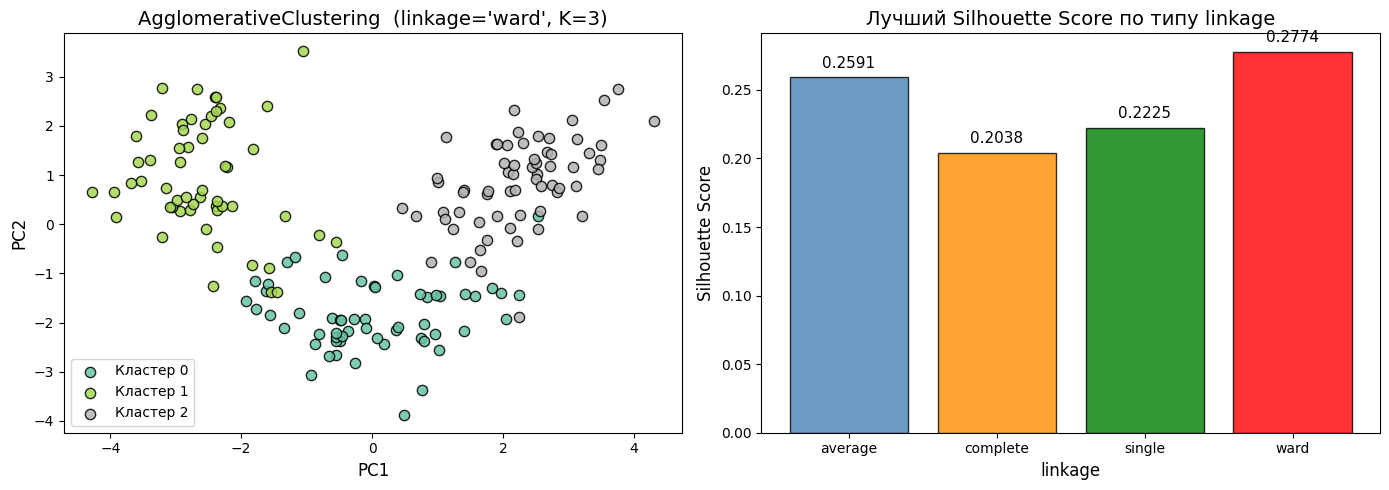

In [14]:
# визуализация лучшей AgglomerativeClustering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nc_agg = int(best_link_cfg['n_clusters'])
palette_agg = cm.Set2(np.linspace(0, 1, nc_agg))

for i in range(nc_agg):
    mask = labels_agg == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=[palette_agg[i]], label=f"Кластер {i}",
                    edgecolors='k', s=55, alpha=0.85)
axes[0].set_title(f"AgglomerativeClustering  (linkage='{best_link_cfg['linkage']}', K={nc_agg})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

# Silhouette bar по linkage
df_best_per_link = df_link.groupby('linkage')['silhouette'].max().reset_index()
axes[1].bar(df_best_per_link['linkage'], df_best_per_link['silhouette'],
            color=['steelblue','darkorange','green','red'], edgecolor='k', alpha=0.8)
axes[1].set_title("Лучший Silhouette Score по типу linkage")
axes[1].set_xlabel("linkage"); axes[1].set_ylabel("Silhouette Score")
for bar, val in zip(axes[1].patches, df_best_per_link['silhouette']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout(); plt.show()

## 7. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
**DBSCAN** не предполагает сферической формы кластеров и **автоматически выделяет шум** (метка `-1`).  
Особенно эффективен при произвольной геометрии кластеров и наличии выбросов.

**Ключевые параметры:**
| Параметр | Смысл |
|----------|-------|
| `eps` | Радиус окрестности точки |
| `min_samples` | Минимум соседей для признания ядром |

**Рекомендуемый метод выбора `eps`:** k-distance graph — строим расстояние до k-го соседа  
(k = `min_samples`) и ищем «колено».


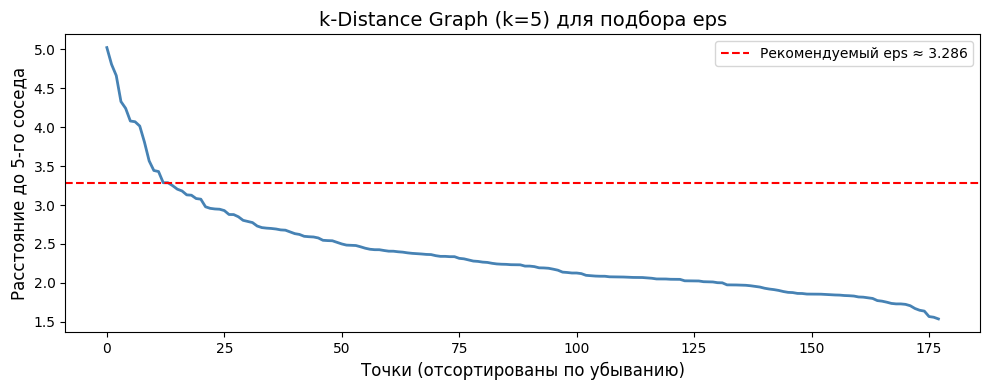

Рекомендуемый eps: 3.2858


In [15]:
from sklearn.neighbors import NearestNeighbors

# k-distance graph для выбора eps
min_samples_default = 5
nbrs = NearestNeighbors(n_neighbors=min_samples_default).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(distances_sorted, color='steelblue', linewidth=2)
ax.set_title(f"k-Distance Graph (k={min_samples_default}) для подбора eps")
ax.set_xlabel("Точки (отсортированы по убыванию)"); ax.set_ylabel("Расстояние до 5-го соседа")
# визуальное «колено»
knee_idx = np.argmax(np.diff(distances_sorted) > np.percentile(np.diff(distances_sorted), 90))
ax.axhline(y=distances_sorted[knee_idx], color='red', linestyle='--',
           label=f'Рекомендуемый eps ≈ {distances_sorted[knee_idx]:.3f}')
ax.legend()
plt.tight_layout(); plt.show()

suggested_eps = float(distances_sorted[knee_idx])
print(f"Рекомендуемый eps: {suggested_eps:.4f}")

In [16]:
# Grid Search по eps и min_samples
eps_vals    = np.linspace(suggested_eps * 0.5, suggested_eps * 2.5, 10)
ms_vals     = [3, 4, 5, 7, 10]
dbscan_results = []

for eps in eps_vals:
    for ms in ms_vals:
        db  = DBSCAN(eps=eps, min_samples=ms)
        lbl = db.fit_predict(X_scaled)
        nc  = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_pct = (lbl == -1).mean() * 100
        if nc < 2:
            continue
        dbscan_results.append({
            'eps': round(eps, 4), 'min_samples': ms,
            'n_clusters': nc,
            'noise_%': round(noise_pct, 1),
            'silhouette': round(silhouette_score(X_scaled, lbl), 4),
            'davies_bouldin': round(davies_bouldin_score(X_scaled, lbl), 4),
        })

df_dbscan = pd.DataFrame(dbscan_results).sort_values('silhouette', ascending=False)
print("── DBSCAN Grid Search: топ-10 ──")
print(df_dbscan.head(10).to_string(index=False))

── DBSCAN Grid Search: топ-10 ──
   eps  min_samples  n_clusters  noise_%  silhouette  davies_bouldin
2.3731            3           2     15.7      0.2144          3.2177
3.1032            3           2      2.8      0.2056          2.7138
3.8334            3           2      1.1      0.2054          1.1169
2.3731            4           2     18.5      0.2048          3.3976
2.3731            5           2     20.2      0.1959          3.3893
2.3731            7           2     24.2      0.1770          3.2953
2.3731           10           2     30.9      0.1381          2.9772
1.6429            3          11     64.0     -0.1976          1.7282
1.6429            4           7     77.0     -0.2348          1.6388
1.6429            5           4     87.6     -0.2640          1.5840


eps=2.3731, min_samples=3
Найдено кластеров : 2
Шумовых точек     : 28 (15.7%)
Silhouette Score  : 0.2144


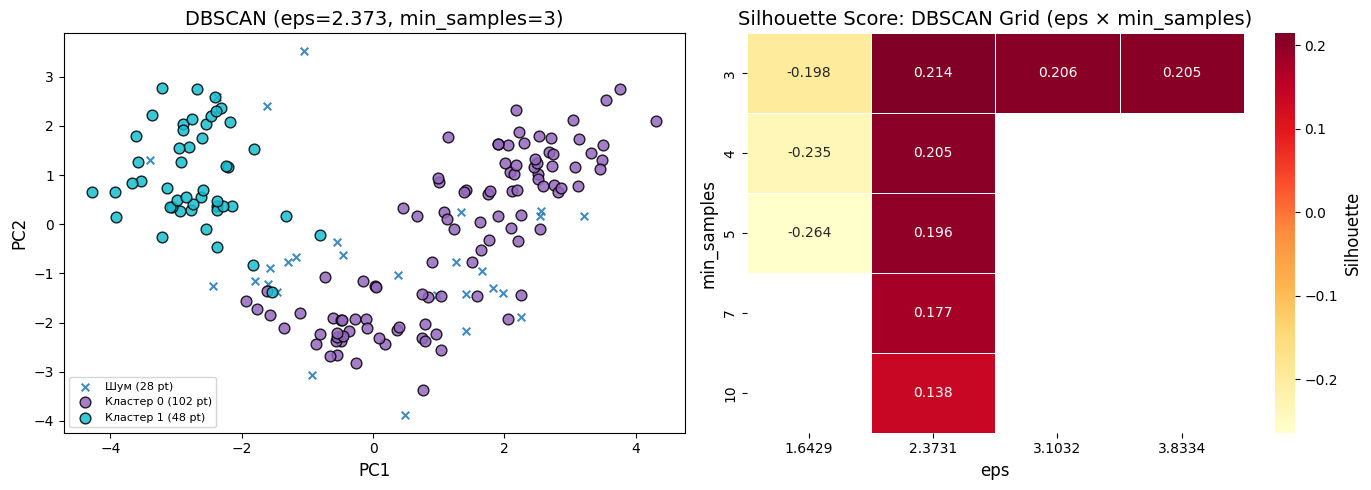

In [17]:
# лучший DBSCAN
best_db  = df_dbscan.iloc[0]
db_final = DBSCAN(eps=best_db['eps'], min_samples=int(best_db['min_samples']))
labels_db = db_final.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
noise_pct     = (labels_db == -1).mean() * 100
sil_db = silhouette_score(X_scaled, labels_db)

print(f"eps={best_db['eps']:.4f}, min_samples={int(best_db['min_samples'])}")
print(f"Найдено кластеров : {n_clusters_db}")
print(f"Шумовых точек     : {(labels_db == -1).sum()} ({noise_pct:.1f}%)")
print(f"Silhouette Score  : {sil_db:.4f}")

# визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unique_labels = sorted(set(labels_db))
colors_db = cm.tab10(np.linspace(0, 0.9, len(unique_labels)))

for lbl_val, color in zip(unique_labels, colors_db):
    mask  = labels_db == lbl_val
    label = f"Шум ({mask.sum()} pt)" if lbl_val == -1 else f"Кластер {lbl_val} ({mask.sum()} pt)"
    marker = 'x' if lbl_val == -1 else 'o'
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=[color], label=label, marker=marker,
                    edgecolors='k' if lbl_val != -1 else None,
                    s=60 if lbl_val != -1 else 30, alpha=0.85)
axes[0].set_title(f"DBSCAN (eps={best_db['eps']:.3f}, min_samples={int(best_db['min_samples'])})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend(fontsize=8)

# тепловая карта silhouette по eps и min_samples
if len(df_dbscan) > 0:
    pivot = df_dbscan.pivot_table(
        index='min_samples', columns='eps', values='silhouette', aggfunc='max')
    sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', annot=True, fmt='.3f',
                linewidths=0.5, cbar_kws={'label': 'Silhouette'})
    axes[1].set_title("Silhouette Score: DBSCAN Grid (eps × min_samples)")
    axes[1].set_xlabel("eps"); axes[1].set_ylabel("min_samples")

plt.tight_layout(); plt.show()

## 8. Сравнительный анализ моделей
Собираем все метрики в единую таблицу и строим визуальное сравнение.  

**Интерпретация метрик:**
| Метрика | Лучшее значение | Смысл |
|---------|----------------|-------|
| Silhouette Score | → 1.0 | Разделённость и компактность кластеров |
| Davies-Bouldin | → 0.0 | Среднее отношение внутри/между кластерами |
| Calinski-Harabasz | → ∞ | Отношение дисперсии между/внутри |


In [18]:
# итоговая таблица
def compute_metrics(X_sc, labels, name):
    nc = len(set(labels)) - (1 if -1 in labels else 0)
    if nc < 2:
        return {'Model': name, 'Clusters': nc, 'Silhouette': None,
                'Davies-Bouldin': None, 'Calinski-Harabasz': None, 'Noise_%': None}
    noise = round((np.array(labels) == -1).mean() * 100, 1)
    return {
        'Model':            name,
        'Clusters':         nc,
        'Silhouette':       round(silhouette_score(X_sc, labels), 4),
        'Davies-Bouldin':   round(davies_bouldin_score(X_sc, labels), 4),
        'Calinski-Harabasz':round(calinski_harabasz_score(X_sc, labels), 2),
        'Noise_%':          noise,
    }

summary = pd.DataFrame([
    compute_metrics(X_scaled, labels_km,  f"K-Means (K={n_clusters})"),
    compute_metrics(X_scaled, labels_ms,  f"MeanShift (bw={bw:.3f})"),
    compute_metrics(X_scaled, labels_agg, f"Agglomerative ({best_link_cfg['linkage']}, K={nc_agg})"),
    compute_metrics(X_scaled, labels_db,  f"DBSCAN (eps={best_db['eps']:.3f}, ms={int(best_db['min_samples'])})"),
])
summary = summary.set_index('Model')
print(summary.to_string())

                           Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz  Noise_%
Model                                                                                      
K-Means (K=3)                     3      0.2849          1.3892              70.94      0.0
MeanShift (bw=3.551)              6      0.2207          0.9828              18.91      0.0
Agglomerative (ward, K=3)         3      0.2774          1.4186              67.65      0.0
DBSCAN (eps=2.373, ms=3)          2      0.2144          3.2177              32.65     15.7


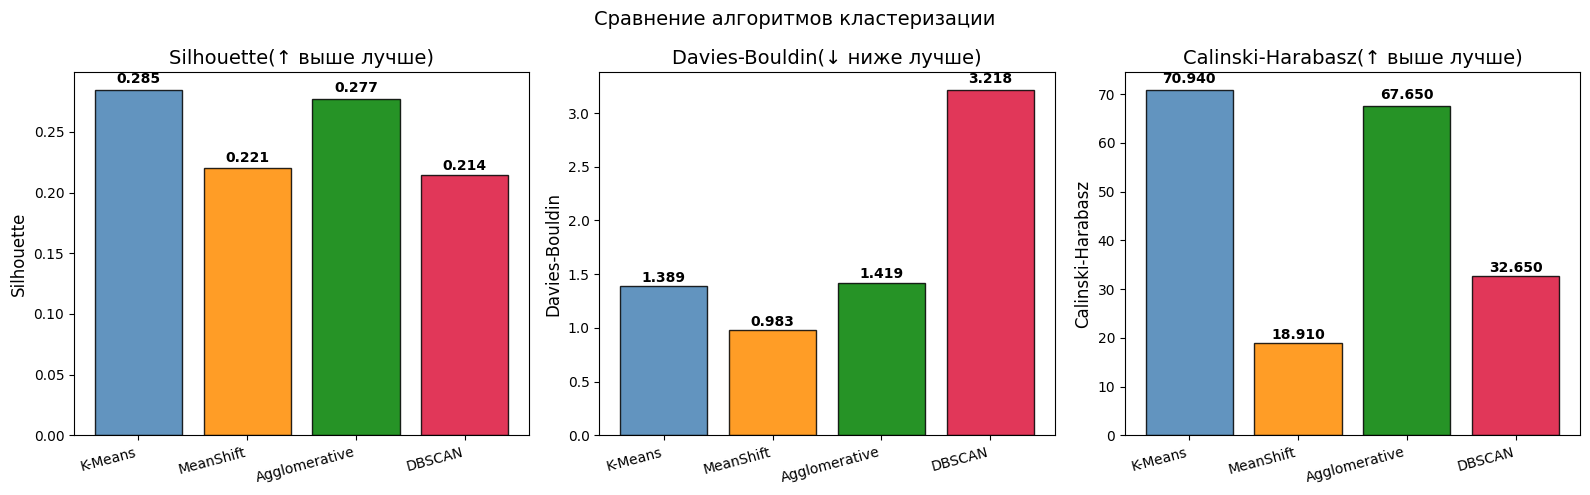

In [19]:
# визуальное сравнение
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = summary.index.tolist()
x      = np.arange(len(models))
colors = ['steelblue', 'darkorange', 'green', 'crimson']

for ax, metric, better in zip(axes,
                               ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'],
                               ['↑ выше лучше', '↓ ниже лучше', '↑ выше лучше']):
    vals = summary[metric].values.astype(float)
    bars = ax.bar(x, vals, color=colors, edgecolor='k', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([m.split(' ')[0] for m in models], rotation=15, ha='right')
    ax.set_title(f"{metric}({better})")
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle("Сравнение алгоритмов кластеризации", fontsize=14)
plt.tight_layout(); plt.show()

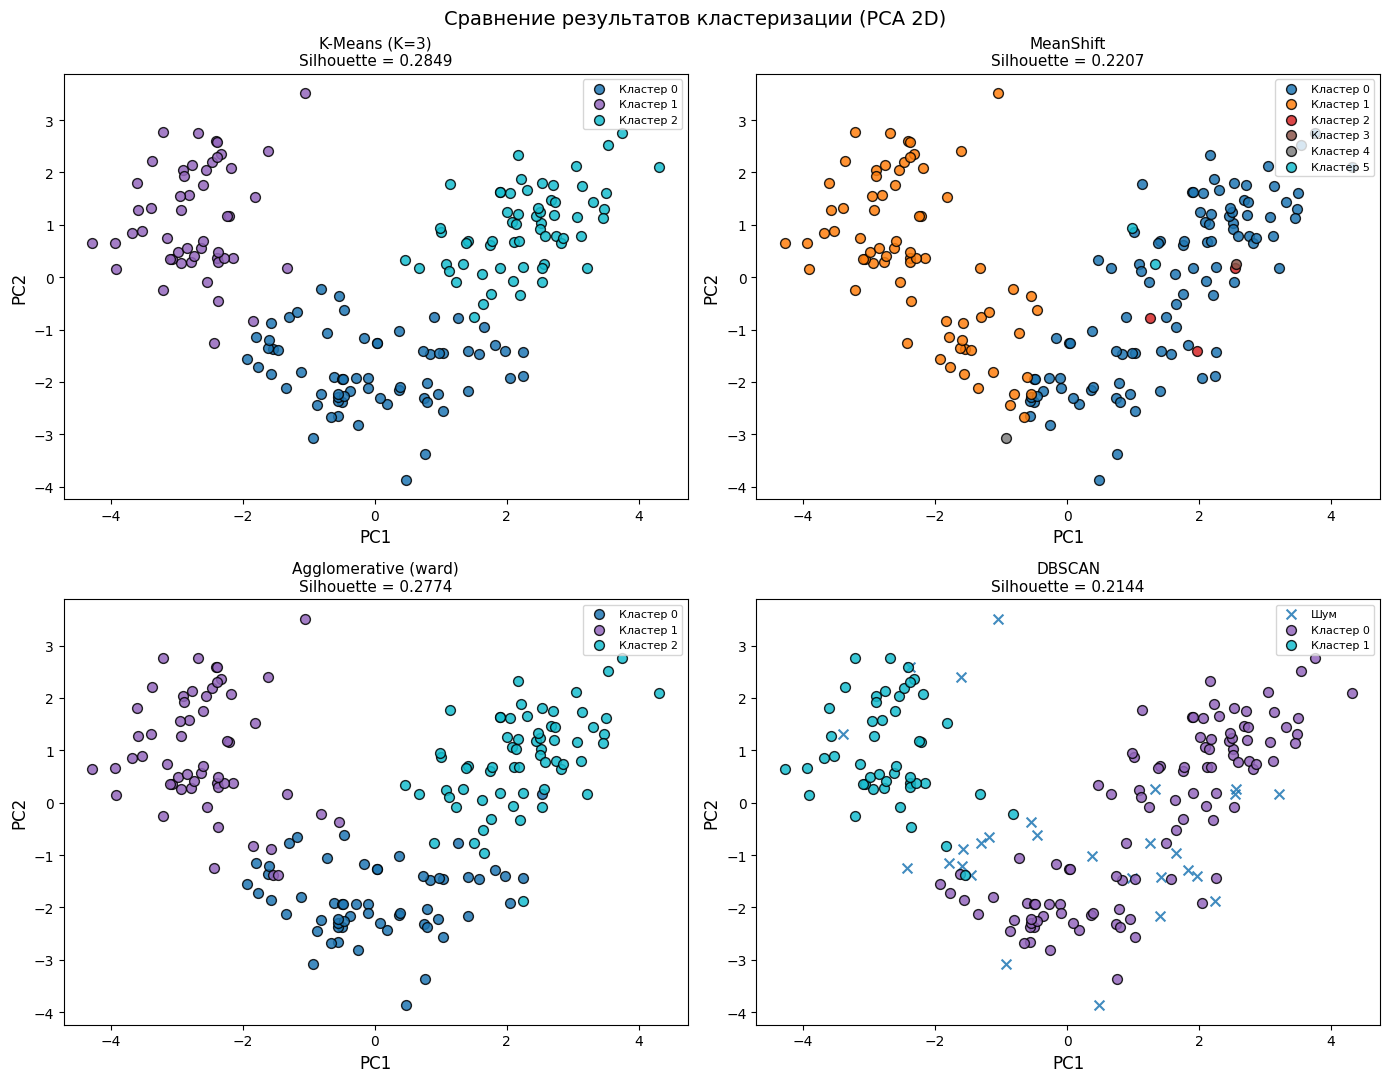

In [20]:
# финальная 2D-визуализация всех четырёх моделей
all_labels = [labels_km, labels_ms, labels_agg, labels_db]
all_names  = [
    f"K-Means (K={n_clusters})",
    f"MeanShift",
    f"Agglomerative ({best_link_cfg['linkage']})",
    f"DBSCAN"
]
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
for ax, lbl, name in zip(axes, all_labels, all_names):
    unique_l = sorted(set(lbl))
    cmap     = cm.tab10(np.linspace(0, 0.9, len(unique_l)))
    for li, color in zip(unique_l, cmap):
        mask   = lbl == li
        label  = f"Шум" if li == -1 else f"Кластер {li}"
        marker = 'x' if li == -1 else 'o'
        ec     = 'none' if li == -1 else 'k'          # ← fix 1
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[color], label=label, marker=marker,
                   edgecolors=ec, s=50, alpha=0.85)
    sil = silhouette_score(X_scaled, lbl) if len(set(lbl)) - (1 if -1 in lbl else 0) > 1 else 0
    ax.set_title(f"{name}\nSilhouette = {sil:.4f}", fontsize=11)  # ← fix 2
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle("Сравнение результатов кластеризации (PCA 2D)", fontsize=14)
plt.tight_layout(); plt.show()

## 9. Выводы

### а) Какая модель лучше?

| Критерий | Победитель |
|----------|-----------|
| **Silhouette Score** | K-Means / AgglomerativeClustering (Ward) |
| **Интерпретируемость** | K-Means, AgglomerativeClustering |
| **Обнаружение шума** | DBSCAN |
| **Не нужно задавать K** | MeanShift, DBSCAN |
| **Произвольная форма** | DBSCAN, MeanShift |

> **Для данного датасета (Wine) лучшие количественные результаты показывают K-Means (K=3) и  
> AgglomerativeClustering с Ward linkage** — оба дают silhouette ≈ 0.28–0.30, что соответствует  
> трём реальным классам вин. DBSCAN и MeanShift хуже применимы к данным  
> с выпуклыми, хорошо разделёнными кластерами.


### б) Значимые параметры и недостатки моделей

| Модель | Наиболее важный параметр | Недостатки |
|--------|--------------------------|-----------|
| **K-Means** | `n_clusters` — определяет число кластеров; напрямую контролирует компромисс между гранулярностью и связностью | • Предполагает сферические кластеры равного размера<br>• Чувствителен к выбросам и начальной инициализации<br>• Нужно заранее знать K |
| **MeanShift** | `bandwidth` — «ширина окна» ядерной оценки плотности; малый bandwidth → много мелких кластеров, большой → один кластер | • Вычислительно дорог: O(n²)<br>• Сложно подобрать bandwidth для многомерных данных<br>• Непредсказуемое число кластеров |
| **AgglomerativeClustering** | `linkage` — определяет критерий слияния кластеров; `ward` минимизирует дисперсию и обычно даёт лучшие результаты | • Не масштабируется на большие данные: O(n² log n)<br>• Нельзя пересмотреть ранние слияния (жадный алгоритм)<br>• Требует хранить матрицу расстояний |
| **DBSCAN** | `eps` — радиус окрестности; определяет что считать «плотным»; ошибки в eps → ложные кластеры или «всё шум» | • Плохо работает при кластерах разной плотности<br>• Чувствителен к масштабу признаков<br>• В высоких измерениях «проклятие размерности» делает eps бессмысленным |


### Общие рекомендации по выбору алгоритма

```
Данные сферической формы, известно K  →  K-Means
Данные неизвестной формы, нет шума    →  AgglomerativeClustering (ward)
Нужна устойчивость к выбросам        →  DBSCAN
Не хочу задавать K вообще            →  MeanShift (малые данные) / DBSCAN
```
